# Case Law Metrics — Validation & Visualization

Every output of `Case law/notebook/*.ipynb` in one place: what is defined, what the
distributions look like, whether the windowed metrics behave monotonically, and whether the
patterns the patent and paper pipelines show survive on a citation network of **5,179,698 court
cases and 47,519,638 citations** spanning 1666–2020.

## Data provenance — please cite

The Case law citation network and metadata used throughout this notebook were **provided by the
authors of**

> Lee, S., Kim, T., Yoon, J., & Youn, H. (2024). *When Common Law Ages: Two Centuries of
> Growing Inertia in US Judicial Opinions.* arXiv preprint
> [arXiv:2410.04493](https://arxiv.org/abs/2410.04493).

`Edge_list.parquet` (47,519,638 citations) and `metadata.csv` (5,179,698 cases) come from that
work. Any use of the `case_*` outputs downstream should cite it.

## Every analysis here starts at 1800

`cl_common.YEAR_MIN = 1800`. Only 1,795 cases (0.035%) predate it, but **14,047 citation edges
point at them**, so the *graph* is left whole — a case decided in 1805 really did cite its 1790
antecedents, and dropping those edges would corrupt its `ref_count`, `CD` and `F/E/G`. The floor
is applied to the population that gets **reported**, not to the network the metrics are computed
on.

## Inputs
| file | |
|---|---|
| `case_metadata.parquet` | decision year, jurisdiction, court, reporter, `ref_count` |
| `case_citation.parquet` | `C_{3,5,10,all}` |
| `case_citation_trend.parquet` | one row per (case, citing year) |
| `case_disruption.parquet` | `CD/F/E/G/ni/nj/nk` × `{3,5,10,all}` |
| `case_feg_disruption_trend.parquet` | the same, averaged by decision year |
| `case_hit_probability.parquet` | citation percentile within (jurisdiction, decision year) |
| `case_sb.parquet` | sleeping-beauty `B`, awakening time `T` |

## What is *not* here, and why

The patent notebook has sections this one cannot: **atypicality** needs journal/venue pairs and
case law has no venue vocabulary to pair; **CPC sections** have no analogue, so jurisdiction
stands in as the field dimension; **team size** needs an author list and a case has judges, not
a normalised author roster; and there is no application-stage network, so no granted-vs-extended
comparison. Those are absences in the data, not omissions in the pipeline.

## The one caveat that governs every time series

The snapshot ends in **2020**, so a fixed window is not comparable across the whole span. A case
decided in 2015 cannot have a closed 10-year window, and `C_all` / `CD_all` get *shorter*
windows the closer a case sits to the snapshot. Every trend plot below marks where the window
closes and draws the truncated tail faint rather than cropping it, so the artefact is visible
instead of silently read as a finding.

In [1]:
import os, sys, gc
import numpy as np, pandas as pd, duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

sys.path.insert(0, '/project/jevans/Dawoon/Science of Science/validation')
sys.path.insert(0, '/project/jevans/Dawoon/Science of Science/Case law')  # cl_common: YEAR_MIN, strata_sql
import val_common as V
V.init('case_law_validation')
C = V.case
META, CIT, TRD = C('case_metadata.parquet'), C('case_citation.parquet'), C('case_citation_trend.parquet')
DIS, FEG = C('case_disruption.parquet'), C('case_feg_disruption_trend.parquet')
HIT, SB = C('case_hit_probability.parquet'), C('case_sb.parquet')

# Slots 1-4 of the reference categorical theme, validated as a set on the light surface.
BLUE, ORANGE, AQUA, VIOLET = '#2a78d6', '#eb6834', '#1baf7a', '#4a3aa7'
INK, MUTED, GRID, SURFACE = '#0b0b0b', '#52514e', '#e6e5e1', '#fcfcfb'
SNAP = 2020                     # last decision year in the snapshot

def style(ax, xlab=None, ylab=None, title=None):
    ax.set_facecolor(SURFACE); ax.grid(axis='y', color=GRID, lw=.8, zorder=0)
    ax.set_axisbelow(True); ax.tick_params(colors=MUTED, length=3)
    for sp in ax.spines.values():
        sp.set_color(GRID)
    if xlab: ax.set_xlabel(xlab, color=MUTED)
    if ylab: ax.set_ylabel(ylab, color=MUTED)
    if title: ax.set_title(title, color=INK, loc='left', pad=8)
    return ax

con = duckdb.connect()
con.execute("SET memory_limit='24GB'")
con.execute(f"SET temp_directory='{V.TMP}'")
con.execute("SET preserve_insertion_order=false")
con.execute("SET enable_progress_bar=false")
V.preflight()

[val] case_law_validation  ->  /project/jevans/Dawoon/Science of Science/validation/Figures/case_law_validation_<section>.{jpg,pdf}  @ 600 dpi
  case_law_validation OK


True

## 1. Coverage — how many cases have each metric defined

`defined` is not the same as `present`. A case with no citers has `CD = NaN` by construction; a
case never cited is absent from `case_sb` entirely but present in `case_citation` with a zero.
Both are correct, and conflating them would silently make every downstream mean conditional on
being cited.

In [2]:
%%time
cov = con.execute(f"""
SELECT 'case_metadata'      AS file, count(*) AS rows, count(decision_year) AS key_defined,
       'decision_year' AS key_col FROM read_parquet('{META}')
UNION ALL SELECT 'case_citation',   count(*), count(*) FILTER (WHERE C_all > 0), 'C_all > 0'
       FROM read_parquet('{CIT}')
UNION ALL SELECT 'case_disruption', count(*), count(CD_all), 'CD_all not null'
       FROM read_parquet('{DIS}')
UNION ALL SELECT 'case_hit_probability', count(*), count(pctl_C_all), 'pctl_C_all not null'
       FROM read_parquet('{HIT}')
UNION ALL SELECT 'case_sb',         count(*), count(*) FILTER (WHERE n_cite >= 5), 'n_cite >= 5'
       FROM read_parquet('{SB}')
UNION ALL SELECT 'case_citation_trend', count(*), count(DISTINCT case_id), 'distinct cases'
       FROM read_parquet('{TRD}')
""").fetchdf()
cov['pct_of_corpus'] = (cov.key_defined / 5_179_698 * 100).round(2)
display(cov)

print('CD defined by window (a case needs at least one citer):')
display(con.execute(f"""SELECT
  round(100.0*count(CD_3)/count(*),2)   AS pct_CD_3,
  round(100.0*count(CD_5)/count(*),2)   AS pct_CD_5,
  round(100.0*count(CD_10)/count(*),2)  AS pct_CD_10,
  round(100.0*count(CD_all)/count(*),2) AS pct_CD_all
  FROM read_parquet('{DIS}')""").fetchdf())

,file,rows,key_defined,key_col,pct_of_corpus
0,case_metadata,5179698,5179698,decision_year,100.00
1,case_citation,5179698,3787861,C_all > 0,73.13
2,case_disruption,5179698,3787861,CD_all not null,73.13
3,case_hit_probability,5177903,5177903,pctl_C_all not null,99.97
4,case_sb,3787861,2133207,n_cite >= 5,41.18
5,case_citation_trend,25816136,3787861,distinct cases,73.13


CD defined by window (a case needs at least one citer):


,pct_CD_3,pct_CD_5,pct_CD_10,pct_CD_all
0,67.21,68.52,70.12,73.13


CPU times: user 1.51 s, sys: 84.8 ms, total: 1.59 s
Wall time: 608 ms


## 2. The corpus in time — decision years

The shape of the corpus governs how every later figure should be read: it is thin before 1850,
grows through the twentieth century, peaks in the 1980s–90s, and thins again at the very end.
The right-hand panel is the same series as a cumulative share, which is the quickest way to see
how little of the corpus the early centuries hold.

/project/jevans/Dawoon/Science of Science/validation/val_common.py:96: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] case_law_validation_2.jpg + .pdf  (600 dpi)


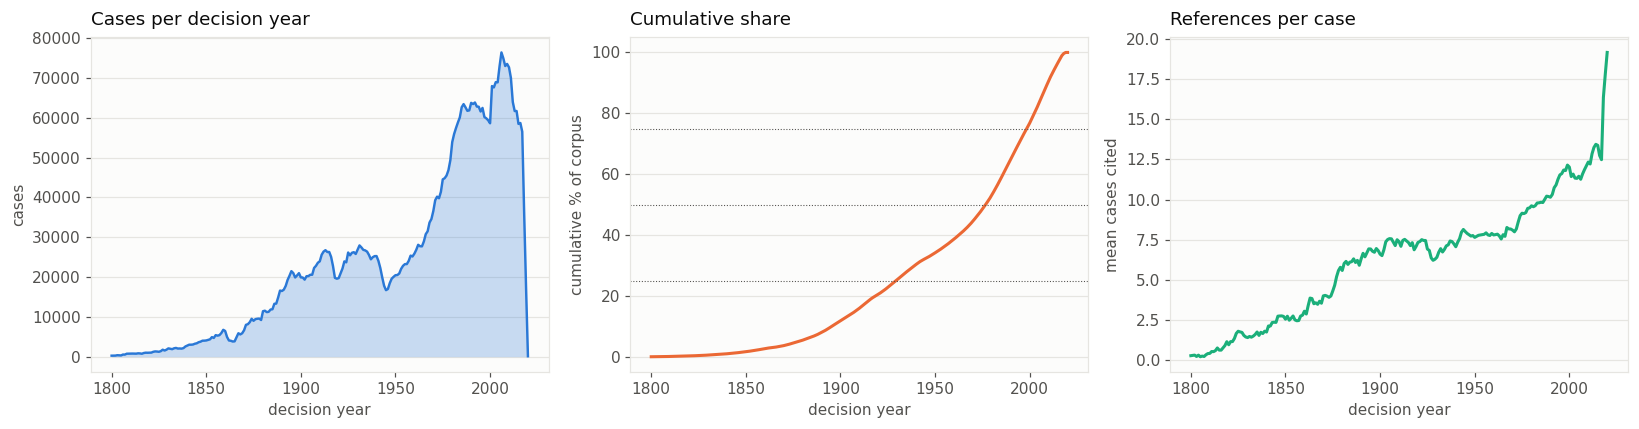

corpus 5,177,903 dated cases, 1800-2020
  25% of the corpus is decided by 1930
  50% of the corpus is decided by 1977
  75% of the corpus is decided by 1999
CPU times: user 1.6 s, sys: 82.6 ms, total: 1.68 s
Wall time: 1.65 s


In [3]:
%%time
yr = con.execute(f"""SELECT decision_year AS year, count(*) AS cases,
  avg(ref_count) AS mean_refs FROM read_parquet('{META}')
  WHERE decision_year >= 1800 GROUP BY 1 ORDER BY 1""").fetchdf()
fig, ax = plt.subplots(1, 3, figsize=(15, 4), layout='constrained')
ax[0].fill_between(yr.year, yr.cases, color=BLUE, alpha=.25, lw=0)
ax[0].plot(yr.year, yr.cases, lw=1.6, color=BLUE)
style(ax[0], 'decision year', 'cases', 'Cases per decision year')
ax[1].plot(yr.year, yr.cases.cumsum() / yr.cases.sum() * 100, lw=2, color=ORANGE)
for q in (25, 50, 75):
    ax[1].axhline(q, color=MUTED, lw=.7, ls=':')
style(ax[1], 'decision year', 'cumulative % of corpus', 'Cumulative share')
ax[2].plot(yr.year, yr.mean_refs, lw=2, color=AQUA)
style(ax[2], 'decision year', 'mean cases cited', 'References per case')
V.save('2')
print(f"corpus {int(yr.cases.sum()):,} dated cases, {int(yr.year.min())}-{int(yr.year.max())}")
for q in (25, 50, 75):
    y = yr.year[(yr.cases.cumsum() / yr.cases.sum() * 100) >= q].iloc[0]
    print(f'  {q}% of the corpus is decided by {int(y)}')

## 3. Forward citations — distributions and windowed monotonicity

`C_3 <= C_5 <= C_10 <= C_all` must hold for **every** case: the windows are nested, so a wider
window cannot count fewer citations. This is the cheapest end-to-end check on the citation
build, and it is asserted rather than eyeballed.

The distribution is the familiar heavy tail. Plotted on log–log with zero-citation cases stated
separately, because they are 27% of the corpus and a log axis cannot show them.

windowed monotonicity violations: 0


,cases,never_cited,mean_C_3,mean_C_5,mean_C_10,mean_C_all,max_C_all
0,5179698,1391837,2.142,3.053,4.715,9.174,69085


never cited: 1,391,837 (26.9%)


/project/jevans/Dawoon/Science of Science/validation/val_common.py:96: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] case_law_validation_3.jpg + .pdf  (600 dpi)


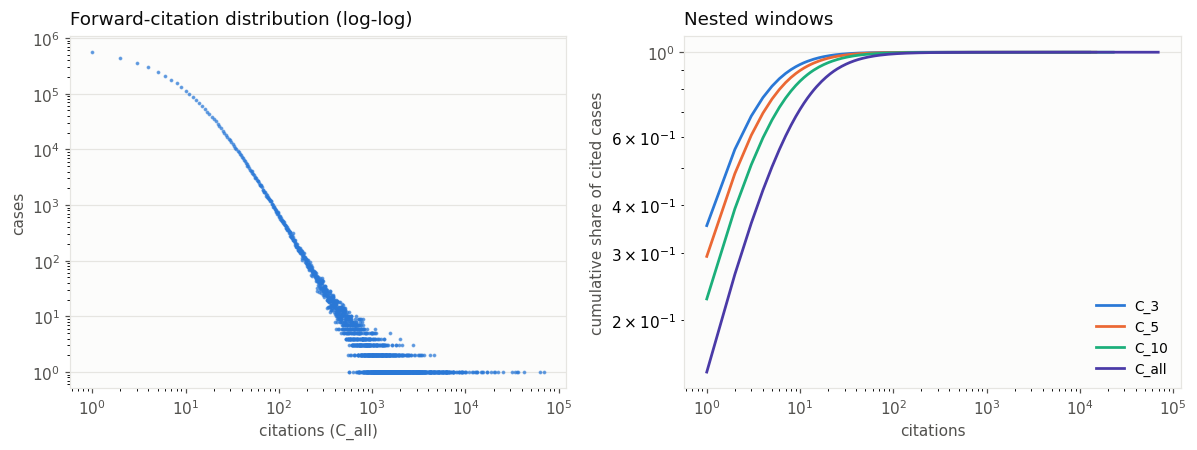

CPU times: user 3.2 s, sys: 93.5 ms, total: 3.3 s
Wall time: 2.65 s


['/project/jevans/Dawoon/Science of Science/validation/Figures/case_law_validation_3.jpg',
 '/project/jevans/Dawoon/Science of Science/validation/Figures/case_law_validation_3.pdf']

In [4]:
%%time
bad = con.execute(f"""SELECT count(*) FROM read_parquet('{CIT}')
  WHERE C_3 > C_5 OR C_5 > C_10 OR C_10 > C_all""").fetchone()[0]
print(f'windowed monotonicity violations: {bad:,}')
assert bad == 0, 'C_3 <= C_5 <= C_10 <= C_all is violated — the citation build is wrong'

st = con.execute(f"""SELECT
  count(*) AS cases,
  count(*) FILTER (WHERE C_all = 0) AS never_cited,
  round(avg(C_3),3) AS mean_C_3, round(avg(C_5),3) AS mean_C_5,
  round(avg(C_10),3) AS mean_C_10, round(avg(C_all),3) AS mean_C_all,
  max(C_all) AS max_C_all FROM read_parquet('{CIT}')""").fetchdf()
display(st)
print(f"never cited: {int(st.never_cited[0]):,} ({st.never_cited[0]/st.cases[0]*100:.1f}%)")

d = con.execute(f"""SELECT C_all, count(*) AS n FROM read_parquet('{CIT}')
  WHERE C_all > 0 GROUP BY 1 ORDER BY 1""").fetchdf()
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), layout='constrained')
ax[0].loglog(d.C_all, d.n, '.', ms=3, color=BLUE, alpha=.6)
style(ax[0], 'citations (C_all)', 'cases', 'Forward-citation distribution (log-log)')
for w, c in (('C_3', BLUE), ('C_5', ORANGE), ('C_10', AQUA), ('C_all', VIOLET)):
    dd = con.execute(f"""SELECT {w} AS v, count(*) AS n FROM read_parquet('{CIT}')
      WHERE {w} > 0 GROUP BY 1 ORDER BY 1""").fetchdf()
    ax[1].loglog(dd.v, dd.n.cumsum() / dd.n.sum(), lw=1.8, color=c, label=w)
style(ax[1], 'citations', 'cumulative share of cited cases', 'Nested windows')
ax[1].legend(frameon=False, fontsize=9)
V.save('3')

## 4. Mean citations by decision year — and the truncation it exposes

The rise-then-collapse at the right of `C_all` is **not** a finding about law. A case decided in
2019 has had one year to be cited; one decided in 1980 has had forty. The dashed guide marks
where each window closes; to its right the series measures elapsed time, not influence.

`C_10` is the honest series for anything up to 2010, and the age profile in §5 is what to use
past that.

/project/jevans/Dawoon/Science of Science/validation/val_common.py:96: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] case_law_validation_4.jpg + .pdf  (600 dpi)


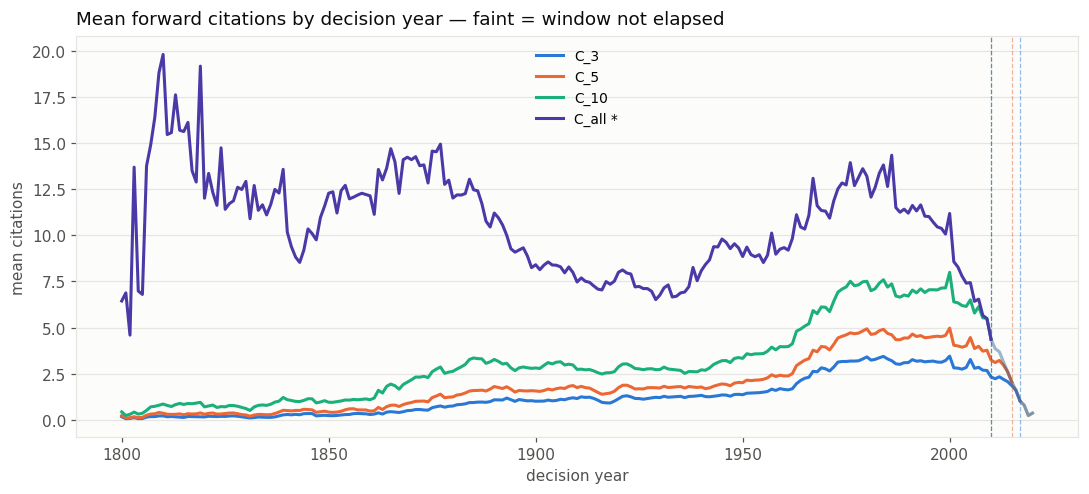

CPU times: user 2.19 s, sys: 124 ms, total: 2.31 s
Wall time: 1.17 s


['/project/jevans/Dawoon/Science of Science/validation/Figures/case_law_validation_4.jpg',
 '/project/jevans/Dawoon/Science of Science/validation/Figures/case_law_validation_4.pdf']

In [5]:
%%time
g = con.execute(f"""
SELECT m.decision_year AS year, count(*) AS n,
       avg(c.C_3) AS C_3, avg(c.C_5) AS C_5, avg(c.C_10) AS C_10, avg(c.C_all) AS C_all
FROM read_parquet('{CIT}') c JOIN read_parquet('{META}') m USING (case_id)
WHERE m.decision_year >= 1800 GROUP BY 1 HAVING count(*) >= 100 ORDER BY 1""").fetchdf()
fig, ax = plt.subplots(figsize=(10, 4.6), layout='constrained')
# An all-time window never 'closes' -- it gets SHORTER the nearer a case sits to the
# snapshot, so it is the series most damaged by truncation, not the least. Mapping it to
# 0 disabled the guard on exactly the wrong series. It is given the widest fixed window's
# horizon (10y) as a conservative stand-in, and the guide is labelled as a stand-in.
CLOSE_H = {'_3': 3, '_5': 5, '_10': 10, '_all': 10}
for col, c in (('C_3', BLUE), ('C_5', ORANGE), ('C_10', AQUA), ('C_all', VIOLET)):
    sfx = '_' + col.split('_', 1)[1]
    closed = SNAP - CLOSE_H[sfx]
    s = g[g.year <= closed]; f = g[g.year >= closed]
    ax.plot(s.year, s[col], lw=2, color=c,
            label=col + (' *' if sfx == '_all' else ''))
    ax.plot(f.year, f[col], lw=2, color=c, alpha=.28)
    ax.axvline(closed, color=c, lw=.8, ls='--', alpha=.5)
style(ax, 'decision year', 'mean citations',
      'Mean forward citations by decision year — faint = window not elapsed')
ax.legend(frameon=False, fontsize=9)
V.save('4')

## 5. Citation age profile — when a case gets cited

From `case_citation_trend.parquet`, which keeps the full history rather than four windows. This
is the shape the windows are cutting through, and it is the part of the citation process that
truncation does *not* destroy: restricting to cases old enough to have the full age range makes
the profile comparable across eras.

The right panel splits the profile by decision era. A flattening or lengthening profile over
time would mean the windows are not comparable across eras even where they have closed — worth
knowing before any window-based claim.

/project/jevans/Dawoon/Science of Science/validation/val_common.py:96: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] case_law_validation_5.jpg + .pdf  (600 dpi)


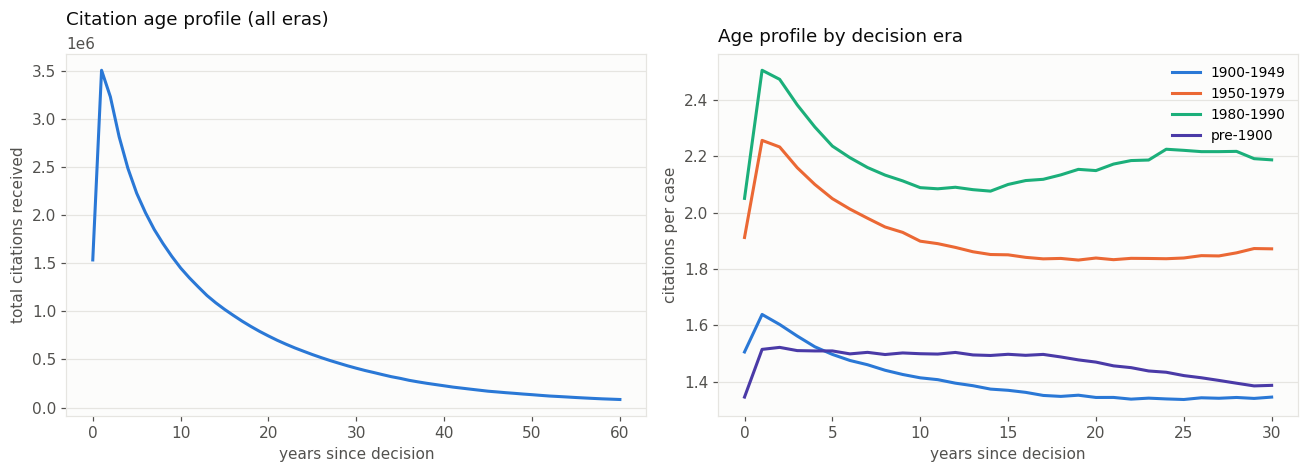

peak citation age (all eras): 1 years
CPU times: user 7.18 s, sys: 260 ms, total: 7.44 s
Wall time: 1.96 s


In [6]:
%%time
age = con.execute(f"""SELECT yrs_since_decision AS age, sum(C) AS cites,
  count(DISTINCT case_id) AS cases FROM read_parquet('{TRD}')
  WHERE yrs_since_decision <= 60 GROUP BY 1 ORDER BY 1""").fetchdf()
era = con.execute(f"""
SELECT CASE WHEN t.decision_year < 1900 THEN 'pre-1900'
            WHEN t.decision_year < 1950 THEN '1900-1949'
            WHEN t.decision_year < 1980 THEN '1950-1979'
            ELSE '1980-1990' END AS era,
       t.yrs_since_decision AS age, sum(t.C)::DOUBLE / count(DISTINCT t.case_id) AS per_case
FROM read_parquet('{TRD}') t
WHERE t.yrs_since_decision <= 30 AND t.decision_year <= 1990
GROUP BY 1, 2 ORDER BY 1, 2""").fetchdf()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4), layout='constrained')
ax[0].plot(age.age, age.cites, lw=2, color=BLUE)
style(ax[0], 'years since decision', 'total citations received', 'Citation age profile (all eras)')
for (e, gg), c in zip(era.groupby('era'), (BLUE, ORANGE, AQUA, VIOLET)):
    ax[1].plot(gg.age, gg.per_case, lw=2, color=c, label=e)
style(ax[1], 'years since decision', 'citations per case', 'Age profile by decision era')
ax[1].legend(frameon=False, fontsize=9)
V.save('5')
print(f'peak citation age (all eras): {int(age.age[age.cites.idxmax()])} years')

## 6. Disruption — CD distribution and the ni / nj / nk composition

CD is bounded in [−1, +1]. Two spikes are expected and are not defects: **CD = +1** is a case
whose citers cite none of its references (`nj = nk = 0`), and **CD = −1** the mirror. Both are
common among cases with very few citers, which is why the panels are split by how many citers
back the number.

The composition panel is the diagnostic that matters: CD is `(ni − nj) / (ni + nj + nk)`, so a
CD drift over time is only interesting once you know *which* of the three terms moved.

/project/jevans/Dawoon/Science of Science/validation/val_common.py:96: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] case_law_validation_6.jpg + .pdf  (600 dpi)


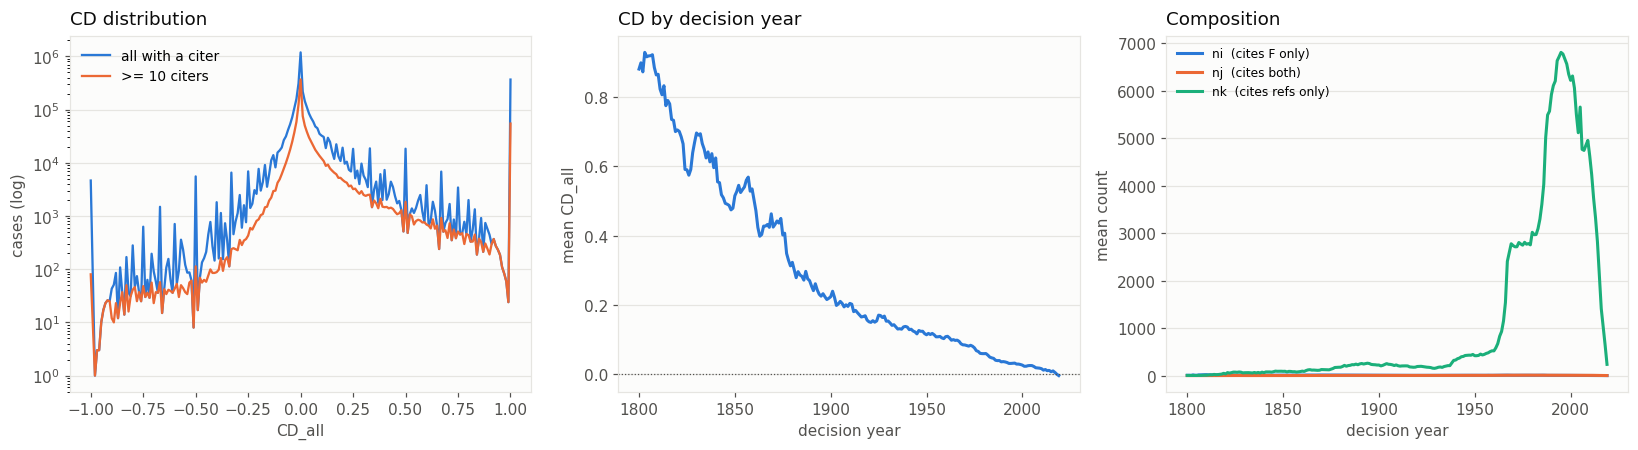

 mean_CD  pct_at_plus1  pct_at_minus1
   0.121          9.66           0.12
CPU times: user 3.82 s, sys: 175 ms, total: 4 s
Wall time: 2.5 s


In [7]:
%%time
h = con.execute(f"""SELECT round(CD_all, 2) AS cd,
  count(*) FILTER (WHERE ni_all + nj_all >= 1)  AS all_cases,
  count(*) FILTER (WHERE ni_all + nj_all >= 10) AS cited10
  FROM read_parquet('{DIS}') WHERE CD_all IS NOT NULL GROUP BY 1 ORDER BY 1""").fetchdf()
comp = con.execute(f"""SELECT m.decision_year AS year, count(*) AS n,
  avg(d.ni_all) AS ni, avg(d.nj_all) AS nj, avg(d.nk_all) AS nk, avg(d.CD_all) AS cd
  FROM read_parquet('{DIS}') d JOIN read_parquet('{META}') m USING (case_id)
  WHERE d.CD_all IS NOT NULL AND m.decision_year >= 1800
  GROUP BY 1 HAVING count(*) >= 100 ORDER BY 1""").fetchdf()

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2), layout='constrained')
ax[0].semilogy(h.cd, h.all_cases, lw=1.5, color=BLUE, label='all with a citer')
ax[0].semilogy(h.cd, h.cited10, lw=1.5, color=ORANGE, label='>= 10 citers')
style(ax[0], 'CD_all', 'cases (log)', 'CD distribution')
ax[0].legend(frameon=False, fontsize=9)
ax[1].plot(comp.year, comp.cd, lw=2, color=BLUE)
ax[1].axhline(0, color=MUTED, lw=.8, ls=':')
style(ax[1], 'decision year', 'mean CD_all', 'CD by decision year')
for col, c, lab in (('ni', BLUE, 'ni  (cites F only)'), ('nj', ORANGE, 'nj  (cites both)'),
                    ('nk', AQUA, 'nk  (cites refs only)')):
    ax[2].plot(comp.year, comp[col], lw=2, color=c, label=lab)
style(ax[2], 'decision year', 'mean count', 'Composition')
ax[2].legend(frameon=False, fontsize=8)
V.save('6')
print(con.execute(f"""SELECT round(avg(CD_all),4) AS mean_CD,
  round(100.0*count(*) FILTER (WHERE CD_all = 1)/count(*),2)  AS pct_at_plus1,
  round(100.0*count(*) FILTER (WHERE CD_all = -1)/count(*),2) AS pct_at_minus1
  FROM read_parquet('{DIS}') WHERE CD_all IS NOT NULL""").fetchdf().to_string(index=False))

## 7. F / E / G — Foundation, Extension, Generalization (5-year window)

All F/E/G here is the **5-year** window. The all-time window never closes — it only gets
shorter the nearer a case sits to the 2020 snapshot — so it is the worst of the four for
comparing across decades, not the best. Five years closes, and by then most cases that will
ever cite a decision have done so (section 5's age profile).

The three shares partition the citers of a case a second way. For a citer *c*, let $e_j$ be how
many of the case's **references** *c* also cites, and $e_i$ how many of the case's **citers** *c*
also cites:

| share | condition | reading |
|---|---|---|
| `E` **extension** | $e_j > e_i$ | *c* leans on the ground the case itself stood on |
| `F` **foundation** | $e_i > e_j$ | *c* leans on what came after the case rather than before |
| `G` **generalization** | $e_j = e_i = 0$ | *c* takes the case on its own, touching neither side |

Ties ($e_j = e_i > 0$) split half and half between `E` and `F`, so `F + E + G = 1` for every case
with a citer — which is exactly what the check below asserts. Naming matches
`patent_validation` §7 and the `cext` / `cfound` counters in the engine, so the patent, paper and
case law families report the same quantity under the same name.

,defined,not_summing_to_1
0,2955914,0


/project/jevans/Dawoon/Science of Science/validation/val_common.py:96: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] case_law_validation_7.jpg + .pdf  (600 dpi)


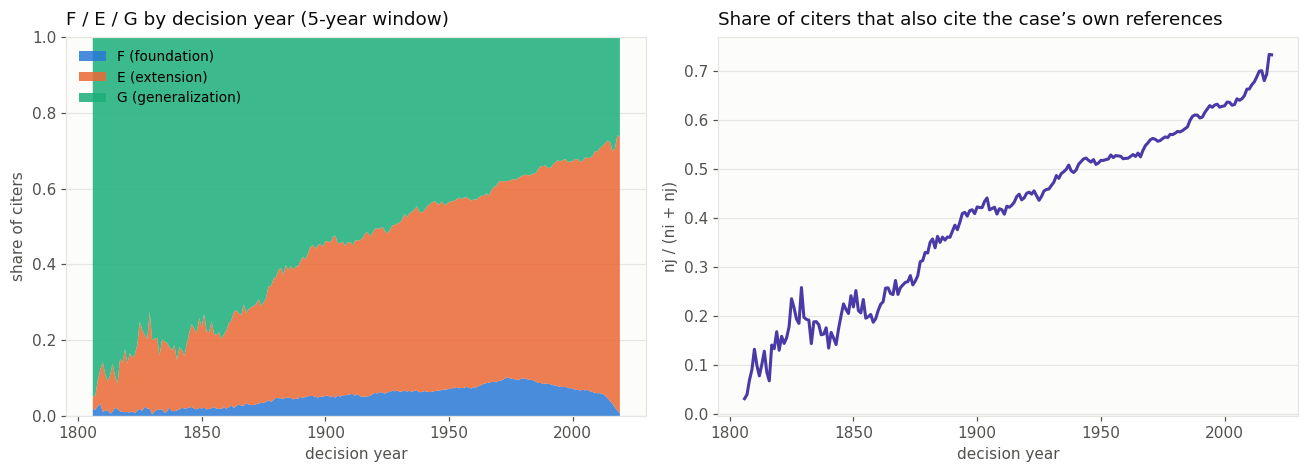

,year,n,n_5_defined,CD_5_mean,F_5_mean,E_5_mean,G_5_mean
211,2011,69995,35122,0.0108,0.0602,0.6473,0.2925
212,2012,63937,32822,0.0131,0.0580,0.6548,0.2872
213,2013,61669,30685,0.0104,0.0537,0.6661,0.2802
214,2014,61680,29841,0.0113,0.0473,0.6800,0.2727
215,2015,58450,26600,0.0075,0.0393,0.6845,0.2762
216,2016,58665,24686,0.0098,0.0323,0.6671,0.3005
217,2017,56482,19276,0.0055,0.0224,0.6839,0.2938
218,2018,36181,11881,0.0003,0.0139,0.7275,0.2586
219,2019,17547,2385,-0.0037,0.0069,0.7296,0.2636
220,2020,130,28,-0.0388,0.0179,0.6690,0.3131


CPU times: user 1.27 s, sys: 70.6 ms, total: 1.34 s
Wall time: 1.21 s


In [8]:
%%time
# F/E/G on the 5-YEAR window. The all-time window has no year at which it closes -- it
# only gets shorter the nearer a document sits to the snapshot -- so it is the worst of
# the four for comparing across time, not the best. Five years closes, and is wide enough
# that most documents that will ever cite have done so.
chk = con.execute(f"""SELECT count(*) AS defined,
  count(*) FILTER (WHERE abs(F_5 + E_5 + G_5 - 1) > 1e-4) AS not_summing_to_1
  FROM read_parquet('{DIS}') WHERE F_5 IS NOT NULL""").fetchdf()
display(chk)
assert int(chk.not_summing_to_1[0]) == 0, 'F + E + G must be 1 for every defined case'

feg = pd.read_parquet(FEG)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4), layout='constrained')
g = feg[feg.n_5_defined >= 100]
ax[0].stackplot(g.year, g.F_5_mean, g.E_5_mean, g.G_5_mean,
                colors=[BLUE, ORANGE, AQUA], labels=['F (foundation)', 'E (extension)', 'G (generalization)'],
                alpha=.85)
style(ax[0], 'decision year', 'share of citers', 'F / E / G by decision year (5-year window)')
ax[0].legend(frameon=False, fontsize=9, loc='upper left'); ax[0].set_ylim(0, 1)
ax[1].plot(g.year, g.njfrac_5_mean, lw=2, color=VIOLET)
style(ax[1], 'decision year', 'nj / (ni + nj)',
      'Share of citers that also cite the case’s own references')
V.save('7')
display(feg[['year','n','n_5_defined','CD_5_mean','F_5_mean','E_5_mean','G_5_mean']]
        .tail(10).round(4))

## 8. Hit percentile — and the zero-inflation a percentile cannot hide

`pctl_C_w` ranks a case inside its `(jurisdiction, decision_year)` cohort. Because 27% of cases
are never cited and ties take the lowest rank, a large block sits at percentile 0 in most
cohorts — so the distribution is **not** uniform, and it should not be. A uniform histogram here
would mean the ties were being broken arbitrarily, which would invent an ordering the data does
not support.

Cohort sizes range from a handful to tens of thousands, so `cohort_n` is plotted too: a
percentile from a six-case cohort carries almost no information.

/project/jevans/Dawoon/Science of Science/validation/val_common.py:96: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] case_law_validation_8.jpg + .pdf  (600 dpi)


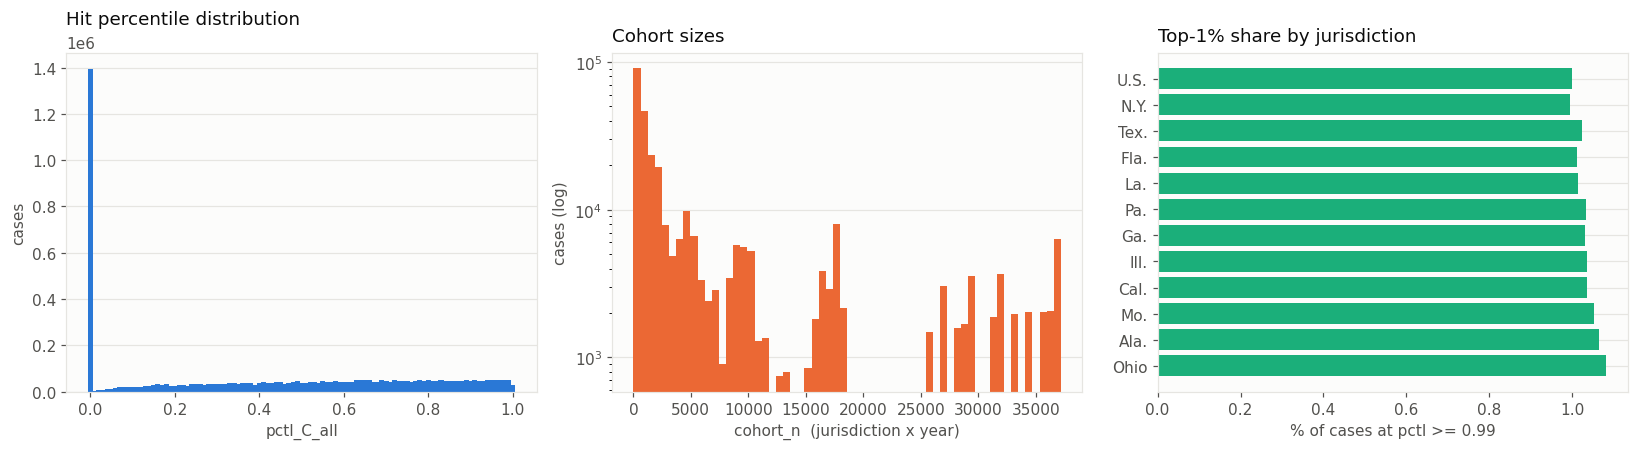

 pct_at_0  mean_cohort  median_cohort  max_cohort
    26.92       6463.0         1591.0       37200


,jurisdiction,cases,pct_top1
0,U.S.,1364193,0.999
1,N.Y.,669625,0.995
2,Tex.,223580,1.023
3,Fla.,214970,1.013
4,La.,188231,1.014
5,Pa.,177510,1.034
6,Ga.,153316,1.031
7,Ill.,150521,1.036
8,Cal.,138050,1.036
9,Mo.,116455,1.053


CPU times: user 4.7 s, sys: 247 ms, total: 4.94 s
Wall time: 2.98 s


In [9]:
%%time
hp = con.execute(f"""SELECT round(pctl_C_all, 2) AS p, count(*) AS n
  FROM read_parquet('{HIT}') GROUP BY 1 ORDER BY 1""").fetchdf()
cn = con.execute(f"""SELECT cohort_n FROM read_parquet('{HIT}') USING SAMPLE 300000 ROWS""").fetchdf()
top = con.execute(f"""
SELECT m.jurisdiction, count(*) AS cases,
       round(100.0*count(*) FILTER (WHERE h.pctl_C_all >= 0.99)/count(*), 3) AS pct_top1
FROM read_parquet('{HIT}') h JOIN read_parquet('{META}') m USING (case_id)
GROUP BY 1 HAVING count(*) >= 20000 ORDER BY cases DESC LIMIT 12""").fetchdf()

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2), layout='constrained')
ax[0].bar(hp.p, hp.n, width=.012, color=BLUE)
style(ax[0], 'pctl_C_all', 'cases', 'Hit percentile distribution')
ax[1].hist(cn.cohort_n, bins=60, color=ORANGE); ax[1].set_yscale('log')
style(ax[1], 'cohort_n  (jurisdiction x year)', 'cases (log)', 'Cohort sizes')
ax[2].barh(top.jurisdiction[::-1], top.pct_top1[::-1], color=AQUA)
style(ax[2], '% of cases at pctl >= 0.99', None, 'Top-1% share by jurisdiction')
V.save('8')
print(con.execute(f"""SELECT round(100.0*count(*) FILTER (WHERE pctl_C_all = 0)/count(*),2) AS pct_at_0,
  round(avg(cohort_n),0) AS mean_cohort, median(cohort_n) AS median_cohort, max(cohort_n) AS max_cohort
  FROM read_parquet('{HIT}')""").fetchdf().to_string(index=False))
display(top)

## 9. By jurisdiction — does the field dimension behave?

Jurisdiction is standing in for what CPC section does in the patent pipeline. If it is a useful
stratum, metric means should differ across jurisdictions by more than noise — and they should
differ in ways that make sense (federal appellate courts cited far more than state trial
courts).

Restricted to jurisdictions with at least 20,000 cases so a mean is worth printing.

,jurisdiction,cases,mean_refs,mean_C_all,mean_C_10,mean_CD_all,mean_ni,mean_nj,mean_SB_B
0,U.S.,1364294,12.29,13.38,7.39,0.0592,8.78,12.27,4.361
1,Mass.,88207,10.14,12.85,4.48,0.1145,8.84,7.24,9.426
2,Md.,39553,13.89,12.23,5.54,0.1009,6.18,7.12,8.159
3,Cal.,138050,11.56,12.15,5.52,0.1004,6.71,6.52,6.392
4,Mo.,116455,11.80,10.80,5.40,0.0795,7.02,5.25,5.542
5,Conn.,47468,10.22,9.90,5.08,0.0884,6.99,6.35,7.050
6,Wis.,45397,9.65,9.64,4.32,0.1105,6.03,4.52,6.133
7,Ind.,81033,9.39,9.45,5.02,0.1197,6.08,4.45,5.983
8,Ala.,106343,10.04,9.39,4.23,0.0831,6.32,5.17,7.498
9,Ariz.,27464,11.49,9.27,5.11,0.0527,5.34,4.85,4.737


/project/jevans/Dawoon/Science of Science/validation/val_common.py:96: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] case_law_validation_9.jpg + .pdf  (600 dpi)


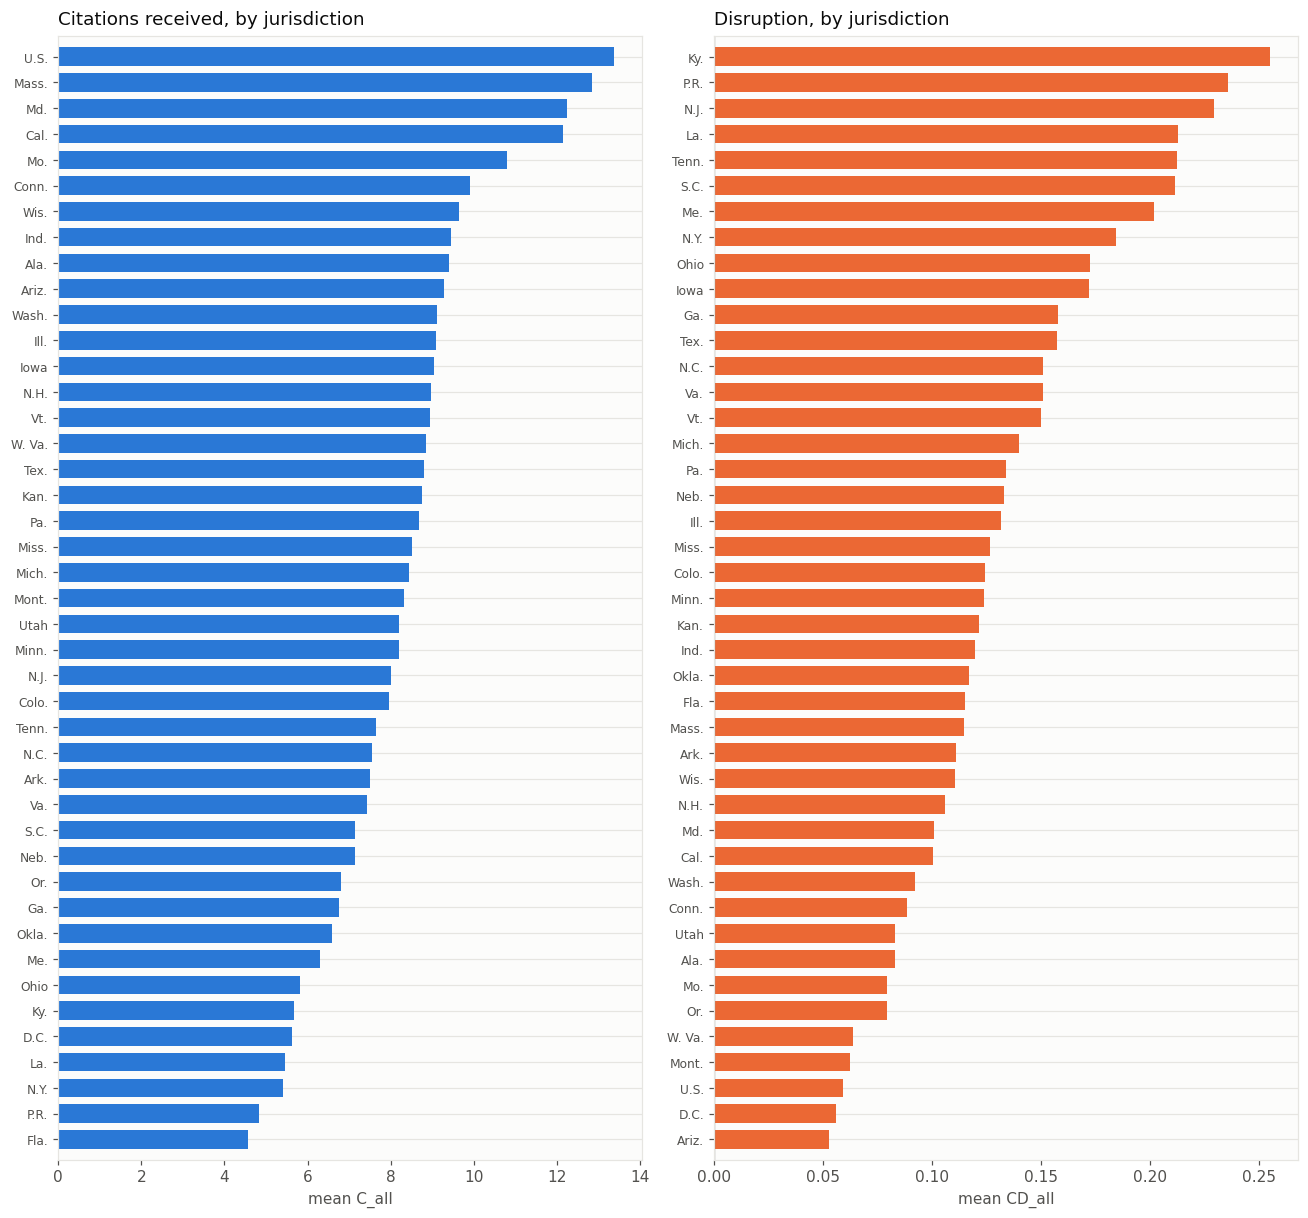

43 jurisdictions >= 20,000 cases -> figure 11.2in tall, 8pt labels
CPU times: user 5.39 s, sys: 323 ms, total: 5.71 s
Wall time: 3.19 s


In [10]:
%%time
byj = con.execute(f"""
SELECT m.jurisdiction, count(*) AS cases,
       round(avg(m.ref_count), 2)  AS mean_refs,
       round(avg(c.C_all), 2)      AS mean_C_all,
       round(avg(c.C_10), 2)       AS mean_C_10,
       round(avg(d.CD_all), 4)     AS mean_CD_all,
       round(avg(d.ni_all), 2)     AS mean_ni,
       round(avg(d.nj_all), 2)     AS mean_nj,
       round(avg(s.SB_B), 3)       AS mean_SB_B
FROM read_parquet('{META}') m
JOIN read_parquet('{CIT}') c USING (case_id)
LEFT JOIN read_parquet('{DIS}') d USING (case_id)
LEFT JOIN read_parquet('{SB}')  s USING (case_id)
GROUP BY 1 HAVING count(*) >= 20000 ORDER BY mean_C_all DESC""").fetchdf()
display(byj)
# 43 jurisdictions clear the 20,000-case floor, so the height has to follow the bar count:
# at a fixed 4.6in the labels are 0.107in apart and a 10pt name is taller than that, which is
# what made them collide. 0.26in per bar plus 8pt ticks leaves clear air between them.
BAR_IN, TICK_PT = 0.26, 8
fig, ax = plt.subplots(1, 2, figsize=(12, max(4.6, BAR_IN * len(byj))),
                       layout='constrained')
for a, (col, colour, lab, title) in zip(ax, [
        ('mean_C_all',  BLUE,   'mean C_all',  'Citations received, by jurisdiction'),
        ('mean_CD_all', ORANGE, 'mean CD_all', 'Disruption, by jurisdiction')]):
    o = byj.sort_values(col)
    a.barh(o.jurisdiction, o[col], color=colour, height=.72)
    style(a, lab, None, title)
    a.tick_params(axis='y', labelsize=TICK_PT)
    a.margins(y=.01)
ax[1].axvline(0, color=MUTED, lw=.8)
V.save('9')
print(f'{len(byj)} jurisdictions >= 20,000 cases -> figure '
      f'{max(4.6, BAR_IN * len(byj)):.1f}in tall, {TICK_PT}pt labels')

## 10. Cross-metric correlations

Spearman on a 500k sample. What to look for: `CD` should be **negatively** related to citation
count (heavily cited cases tend to be consolidating, the pattern the patent and paper pipelines
both show), `ref_count` should relate positively to `nj` (more references means more chances for
a citer to share one), and the hit percentile should track `C_all` almost perfectly — it is a
monotone transform of it within cohorts, so anything much below 0.9 would mean the cohorting is
broken.

  [fig] case_law_validation_10.jpg + .pdf  (600 dpi)


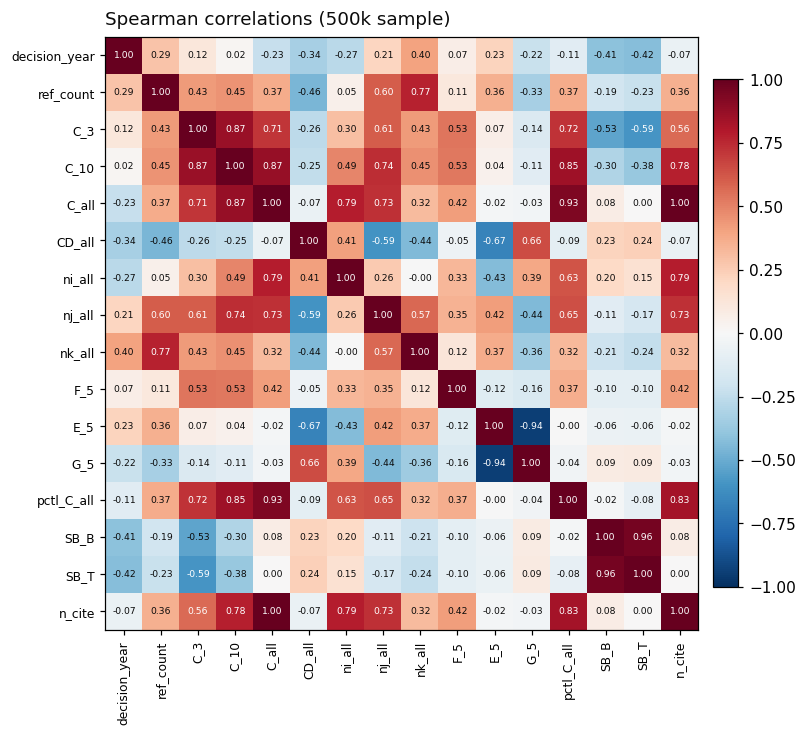

key relationships:
  C_all        vs CD_all       -0.068
  C_all        vs pctl_C_all   +0.932
  ref_count    vs nj_all       +0.603
  ref_count    vs CD_all       -0.457
  n_cite       vs SB_B         +0.075
CPU times: user 21.9 s, sys: 950 ms, total: 22.8 s
Wall time: 15.3 s


In [11]:
%%time
smp = con.execute(f"""
SELECT m.decision_year, m.ref_count, c.C_3, c.C_10, c.C_all,
       d.CD_all, d.ni_all, d.nj_all, d.nk_all, d.F_5, d.E_5, d.G_5,
       h.pctl_C_all, s.SB_B, s.SB_T, s.n_cite
FROM read_parquet('{META}') m
JOIN read_parquet('{CIT}') c USING (case_id)
LEFT JOIN read_parquet('{DIS}') d USING (case_id)
LEFT JOIN read_parquet('{HIT}') h USING (case_id)
LEFT JOIN read_parquet('{SB}')  s USING (case_id)
USING SAMPLE 500000 ROWS""").fetchdf()
cr = smp.corr(method='spearman', numeric_only=True)
fig, ax = plt.subplots(figsize=(8.5, 7), layout='constrained')
im = ax.imshow(cr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cr))); ax.set_xticklabels(cr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(cr))); ax.set_yticklabels(cr.columns, fontsize=8)
for i in range(len(cr)):
    for j in range(len(cr)):
        v = cr.iloc[i, j]
        if np.isfinite(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                    color='white' if abs(v) > .55 else INK)
ax.set_title('Spearman correlations (500k sample)', color=INK, loc='left', pad=8)
fig.colorbar(im, ax=ax, fraction=.035, pad=.02)
V.save('10')
print('key relationships:')
for a, b in (('C_all','CD_all'), ('C_all','pctl_C_all'), ('ref_count','nj_all'),
             ('ref_count','CD_all'), ('n_cite','SB_B')):
    print(f'  {a:<12} vs {b:<12} {cr.loc[a,b]:+.3f}')

## 11. Sleeping Beauties

`B` is large when a case is ignored for years and then cited heavily. `B = 0` is not a missing
value — it is a case whose citations peak in its own decision year, which by the definition is
not a sleeping beauty at all.

`B` is meaningless on two or three citations, so everything below is restricted to
`n_cite >= 50`. The right panel is the check that the coefficient means what it says: the
awakening time `T` of high-`B` cases should sit well away from zero.

126,752 cases with >= 50 citations
  SB_B  median 2.03  p99 148.5  max 4683
  B == 0 (peaks at decision): 19.0%


/project/jevans/Dawoon/Science of Science/validation/val_common.py:96: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] case_law_validation_11.jpg + .pdf  (600 dpi)


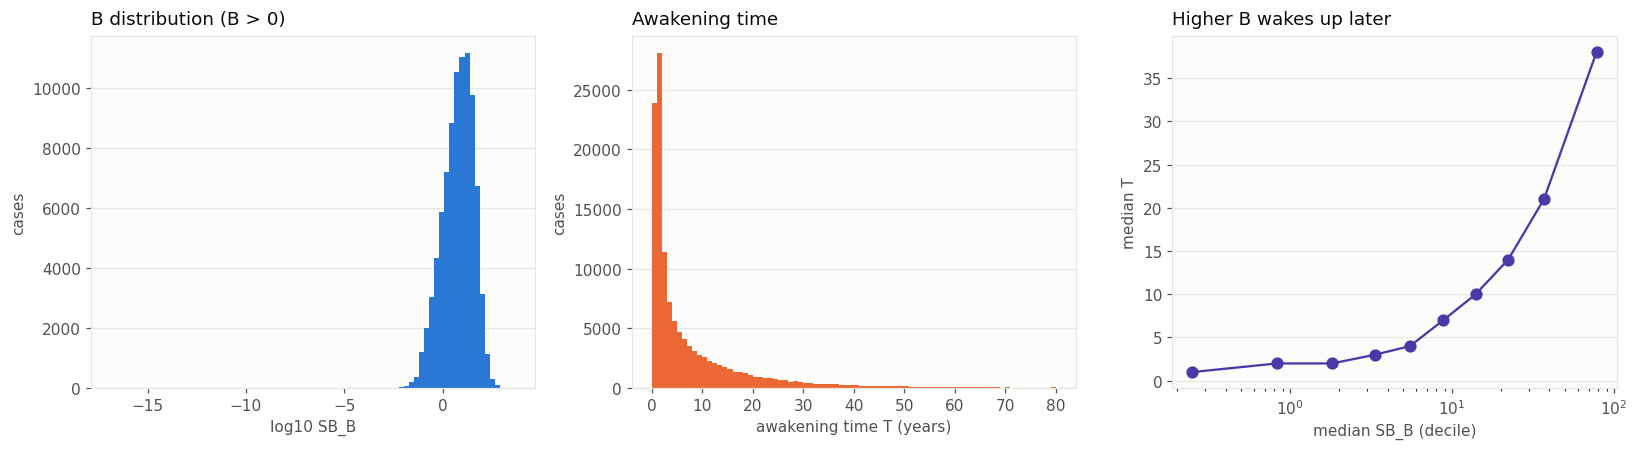

,case_id,name_abbreviation,decision_year,jurisdiction,SB_B,SB_T,n_cite
0,10591698,United States v. Hooton,1982,U.S.,4682.804688,23,1314
1,12121367,United States v. Schooner Peggy,1801,U.S.,3454.337891,162,492
2,12121622,Marbury v. Madison,1803,U.S.,3300.233887,159,2878
3,8294520,United States v. Detroit Timber & Lumber Co.,1906,U.S.,3153.725098,106,335
4,6627259,Society for the Propagation of the Gospel v. W...,1814,U.S.,2825.310059,177,223
5,11749315,Hayburn's case,1792,U.S.,2499.779297,184,321
6,1421261,United States v. Perez,1824,U.S.,2233.148193,145,1219
7,6142415,Rooker v. Fidelity Trust Co.,1923,U.S.,2028.850952,70,2713
8,1427693,Strawbridge v. Curtiss,1806,U.S.,1635.648682,158,1176
9,11720199,Frye v. United States,1923,U.S.,1613.138794,57,3000


CPU times: user 2.76 s, sys: 162 ms, total: 2.92 s
Wall time: 2.3 s


In [12]:
%%time
sb = con.execute(f"""SELECT SB_B, SB_T, n_cite FROM read_parquet('{SB}')
  WHERE n_cite >= 50""").fetchdf()
print(f'{len(sb):,} cases with >= 50 citations')
print(f'  SB_B  median {sb.SB_B.median():.2f}  p99 {sb.SB_B.quantile(.99):.1f}  max {sb.SB_B.max():.0f}')
print(f'  B == 0 (peaks at decision): {(sb.SB_B==0).mean()*100:.1f}%')

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2), layout='constrained')
pos = sb[sb.SB_B > 0]
ax[0].hist(np.log10(pos.SB_B), bins=80, color=BLUE)
style(ax[0], 'log10 SB_B', 'cases', 'B distribution (B > 0)')
ax[1].hist(sb.SB_T, bins=range(0, 81), color=ORANGE)
style(ax[1], 'awakening time T (years)', 'cases', 'Awakening time')
q = pd.qcut(pos.SB_B, 10, labels=False, duplicates='drop')
gg = pos.groupby(q).agg(B=('SB_B','median'), T=('SB_T','median'), n=('n_cite','median'))
assert list(gg.columns) == ['B','T','n']
# gg['T'], never gg.T -- the attribute is the DataFrame transpose, which is a (3, 10)
# array and fails against a 10-element x with a shape error rather than a name error.
ax[2].plot(gg['B'], gg['T'], 'o-', color=VIOLET, ms=7)
ax[2].set_xscale('log')
style(ax[2], 'median SB_B (decile)', 'median T', 'Higher B wakes up later')
V.save('11')
top = con.execute(f"""SELECT s.case_id, m.name_abbreviation, m.decision_year, m.jurisdiction,
  s.SB_B, s.SB_T, s.n_cite FROM read_parquet('{SB}') s JOIN read_parquet('{META}') m USING (case_id)
  WHERE s.n_cite >= 100 ORDER BY s.SB_B DESC LIMIT 12""").fetchdf()
display(top)

## 11b. Sleeping beauties across the three families — papers, patents, cases

The three pipelines compute `B` with the **same kernel**: `_sb_one` in `paper_sb.ipynb`,
`patent_sb.ipynb` and `case_sb.ipynb` is the same function — same normalisation
$\sqrt{(c_m-c_0)^2 + t_m^2}$, same rule that a curve peaking in year 0 gets `B = 0` rather than
a missing value. So `B` is directly comparable across them, and this section is the one place
in the project where it is put side by side.

Each family is filtered to `n_cite >= 100`, because `B` is dominated by noise on a handful of
citations and the three corpora have very different citation levels.

## What identifies a document differs by family, and that limits the table

Case law is the only one of the three with a human-readable name in its metadata
(`name_abbreviation`), so its rows can be read directly. `patent_metadata` has no title — the
closest labels are CPC code and assignee. `paper_metadata` has no title either, and its
`author_list` is 100% null (`RUN_AUTHORS=False`), so a paper is identified by journal and field.
The ids are printed in full for all three so any row can be looked up.

sb files present: {'paper': True, 'patent': True, 'case': True}


,documents,B == 0 (%),B median,B p99,B max,T median,T p99,n_cite median
paper,3731824.0,5.1,0.84,316.4,10541546.0,3.0,48.0,158.0
patent,210545.0,0.7,24.32,566.4,3427.0,9.0,33.0,158.0
case,38288.0,17.1,1.16,224.1,4683.0,3.0,73.0,149.0


/project/jevans/Dawoon/Science of Science/validation/val_common.py:96: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] case_law_validation_11b.jpg + .pdf  (600 dpi)


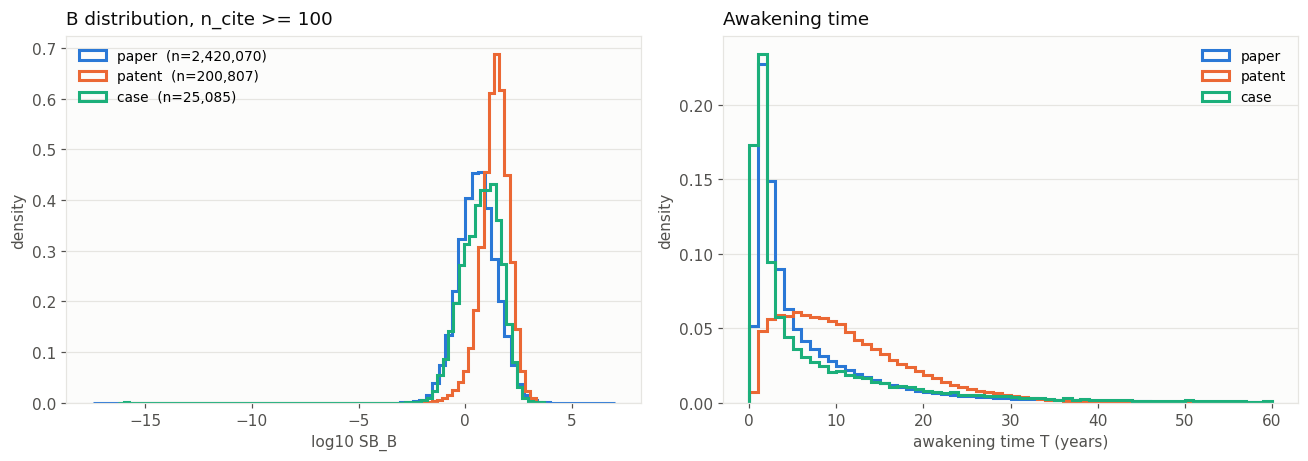

CPU times: user 5.99 s, sys: 1.16 s, total: 7.16 s
Wall time: 3.58 s


['/project/jevans/Dawoon/Science of Science/validation/Figures/case_law_validation_11b.jpg',
 '/project/jevans/Dawoon/Science of Science/validation/Figures/case_law_validation_11b.pdf']

In [13]:
%%time
PAPER_SB, PAPER_META = V.paper('paper_sb.parquet'), V.paper('paper_metadata.parquet')
PAT_SB,   PAT_META   = V.patent('patent_sb.parquet'), V.patent('patent_metadata.parquet')
MIN_CITE, TOPN = 100, 12
avail = {k: os.path.exists(v) for k, v in
         [('paper', PAPER_SB), ('patent', PAT_SB), ('case', SB)]}
print('sb files present:', avail)

# ---- distributions on a common axis -------------------------------------------------------
dist = {}
for fam, f, idc in (('paper', PAPER_SB, 'paper_id'), ('patent', PAT_SB, 'patent_id'),
                    ('case', SB, 'case_id')):
    if not avail[fam]:
        continue
    dist[fam] = con.execute(f"""SELECT SB_B, SB_T, n_cite FROM read_parquet('{f}')
      WHERE n_cite >= {MIN_CITE}""").fetchdf()

stats = pd.DataFrame({fam: {
    'documents':    len(d),
    'B == 0 (%)':   round((d.SB_B == 0).mean() * 100, 1),
    'B median':     round(d.SB_B.median(), 2),
    'B p99':        round(d.SB_B.quantile(.99), 1),
    'B max':        round(d.SB_B.max(), 0),
    'T median':     int(d.SB_T.median()),
    'T p99':        int(d.SB_T.quantile(.99)),
    'n_cite median': int(d.n_cite.median()),
} for fam, d in dist.items()}).T
display(stats)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3), layout='constrained')
for (fam, d), c in zip(dist.items(), (BLUE, ORANGE, AQUA)):
    pos = d[d.SB_B > 0]
    ax[0].hist(np.log10(pos.SB_B), bins=80, histtype='step', lw=2, color=c,
               density=True, label=f'{fam}  (n={len(pos):,})')
    ax[1].hist(d.SB_T, bins=range(0, 61), histtype='step', lw=2, color=c,
               density=True, label=fam)
style(ax[0], 'log10 SB_B', 'density', f'B distribution, n_cite >= {MIN_CITE}')
ax[0].legend(frameon=False, fontsize=9)
style(ax[1], 'awakening time T (years)', 'density', 'Awakening time')
ax[1].legend(frameon=False, fontsize=9)
V.save('11b')

In [14]:
%%time
# ---- the top sleeping beauties of each family ----------------------------------------------
if avail['case']:
    print(f'=== CASE LAW — top {TOPN} by B  (n_cite >= {MIN_CITE}) ===')
    display(con.execute(f"""
    SELECT s.case_id, m.name_abbreviation AS name, m.decision_year AS year,
           m.jurisdiction, m.court, round(s.SB_B, 1) AS SB_B, s.SB_T, s.n_cite
    FROM read_parquet('{SB}') s JOIN read_parquet('{META}') m USING (case_id)
    WHERE s.n_cite >= {MIN_CITE} ORDER BY s.SB_B DESC LIMIT {TOPN}""").fetchdf())

if avail['patent']:
    print(f'=== PATENTS — top {TOPN} by B  (no title in patent_metadata; CPC + assignee stand in) ===')
    display(con.execute(f"""
    SELECT s.patent_id, m.grant_year, m.cpc_code,
           substr(coalesce(m.assignee_list, ''), 1, 46) AS assignee,
           round(s.SB_B, 1) AS SB_B, s.SB_T, s.n_cite
    FROM read_parquet('{PAT_SB}') s JOIN read_parquet('{PAT_META}') m USING (patent_id)
    WHERE s.n_cite >= {MIN_CITE} ORDER BY s.SB_B DESC LIMIT {TOPN}""").fetchdf())

if avail['paper']:
    print(f'=== PAPERS — top {TOPN} by B  (no title in paper_metadata; journal + field stand in) ===')
    display(con.execute(f"""
    SELECT s.paper_id, m.year, m.doctype, substr(coalesce(m.journal, ''), 1, 40) AS journal,
           m.FoS_rep AS field, round(s.SB_B, 1) AS SB_B, s.SB_T, s.n_cite
    FROM read_parquet('{PAPER_SB}') s JOIN read_parquet('{PAPER_META}') m
      ON m.paper_id = s.paper_id
    WHERE s.n_cite >= {MIN_CITE} ORDER BY s.SB_B DESC LIMIT {TOPN}""").fetchdf())

=== CASE LAW — top 12 by B  (n_cite >= 100) ===


,case_id,name,year,jurisdiction,court,SB_B,SB_T,n_cite
0,10591698,United States v. Hooton,1982,U.S.,9th Cir.,4682.799805,23,1314
1,12121367,United States v. Schooner Peggy,1801,U.S.,U.S.,3454.300049,162,492
2,12121622,Marbury v. Madison,1803,U.S.,U.S.,3300.199951,159,2878
3,8294520,United States v. Detroit Timber & Lumber Co.,1906,U.S.,U.S.,3153.699951,106,335
4,6627259,Society for the Propagation of the Gospel v. W...,1814,U.S.,C.C.D.N.H.,2825.300049,177,223
5,11749315,Hayburn's case,1792,U.S.,U.S.,2499.800049,184,321
6,1421261,United States v. Perez,1824,U.S.,U.S.,2233.100098,145,1219
7,6142415,Rooker v. Fidelity Trust Co.,1923,U.S.,U.S.,2028.900024,70,2713
8,1427693,Strawbridge v. Curtiss,1806,U.S.,U.S.,1635.599976,158,1176
9,11720199,Frye v. United States,1923,U.S.,D.C. Cir.,1613.099976,57,3000


=== PATENTS — top 12 by B  (no title in patent_metadata; CPC + assignee stand in) ===


,patent_id,grant_year,cpc_code,assignee,SB_B,SB_T,n_cite
0,4149461,1979,B41F13/26,e9234470-e19a-4b28-b76a-f22dfe01eb10,3426.600098,42,436
1,3972734,1976,H01M6/36,f568c313-a107-4a80-88b8-79df48ec6976,3255.199951,42,1011
2,4034143,1977,H01M6/46,f568c313-a107-4a80-88b8-79df48ec6976,3169.800049,41,1009
3,3944163,1976,B60R22/353,74c11be2-20ec-49fe-ac26-d839d375bd32,3076.500000,42,1025
4,4250817,1981,F27B9/36,a4954402-5f7a-4911-b282-3a502ef442b6,3058.800049,41,349
5,4293604,1981,D04H11/00,08dcb35e-70b2-4c84-b57c-02ad169716cc,3009.600098,38,825
6,4154122,1979,B25B13/46,,2994.100098,39,1017
7,4282573,1981,F02P5/1502,93f8c962-7a18-45c0-b192-7a141f9a8b6c,2964.300049,38,701
8,4027746,1977,B62L1/16,8d3fcc3b-4e45-42f7-9198-3bf3eebffff5,2946.699951,41,1027
9,4160857,1979,H01M6/44,6f1d2af2-ef87-47e7-824f-eba7835a329f,2938.500000,41,601


=== PAPERS — top 12 by B  (no title in paper_metadata; journal + field stand in) ===


,paper_id,year,doctype,journal,field,SB_B,SB_T,n_cite
0,W2007442728,1999.0,article,Review of Scientific Instruments,Engineering,10541546.0,24,1033592
1,W1978608505,2006.0,article,Plasma and Fusion Research,Physics and Astronomy,6743336.5,17,1282814
2,W2053472650,1999.0,article,Plasma Physics and Controlled Fusion,Physics and Astronomy,6306505.5,24,663667
3,W1994173793,2001.0,article,Review of Scientific Instruments,Physics and Astronomy,5259485.5,22,547190
4,W2131038366,1984.0,article,Journal of Nuclear Materials,Physics and Astronomy,5209826.0,39,334049
5,W1969035145,2008.0,article,Review of Scientific Instruments,Physics and Astronomy,5082060.5,15,1260028
6,W2036929842,2000.0,article,Review of Scientific Instruments,Engineering,4870302.0,23,547195
7,W2000536338,2011.0,article,Plasma and Fusion Research,Engineering,4743740.0,12,1033568
8,W2055167159,1993.0,article,Journal of Vacuum Science & Technology A,Physics and Astronomy,4597735.5,30,334018
9,W2023185708,2013.0,article,Plasma and Fusion Research,Physics and Astronomy,4499379.5,11,826421


CPU times: user 53.5 s, sys: 2.85 s, total: 56.4 s
Wall time: 9.09 s


family,case,paper,patent
B >=,,,
10,26.9902,19.9110,71.8497
50,8.6111,6.7015,29.8060
100,3.7270,3.6179,14.7731
500,0.1854,0.5471,1.2719


/project/jevans/Dawoon/Science of Science/validation/val_common.py:96: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] case_law_validation_11c.jpg + .pdf  (600 dpi)


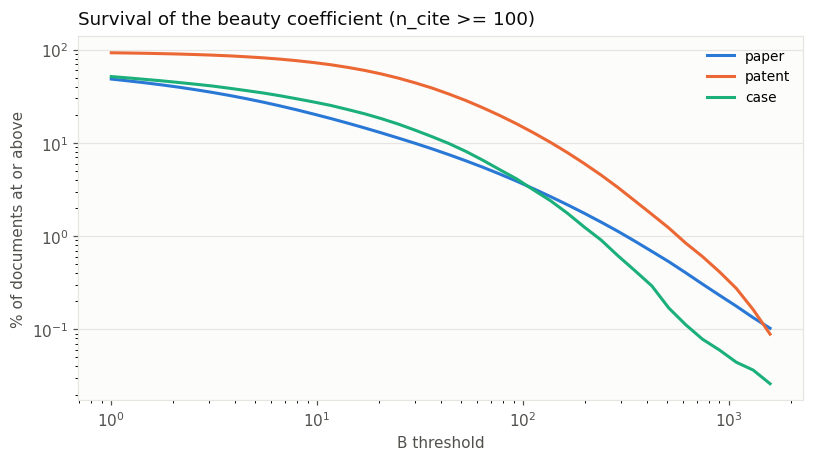

Same kernel, same n_cite floor, so the ordering of these curves is a statement about
the citation cultures, not about the implementations.
CPU times: user 1.77 s, sys: 47.2 ms, total: 1.82 s
Wall time: 1.44 s


In [15]:
%%time
# ---- is a sleeping beauty rarer in one family than another? -------------------------------
# The share above a common B threshold, at a common n_cite floor, is the comparable statistic:
# a raw count is dominated by the corpora being 88M / 6.8M / 3.8M documents.
rows = []
for fam, d in dist.items():
    for thr in (10, 50, 100, 500):
        rows.append({'family': fam, 'B >=': thr,
                     'pct_of_docs': round((d.SB_B >= thr).mean() * 100, 4),
                     'n_docs': int((d.SB_B >= thr).sum())})
share = pd.DataFrame(rows).pivot(index='B >=', columns='family',
                                 values='pct_of_docs')
display(share)

fig, ax = plt.subplots(figsize=(7.5, 4.3), layout='constrained')
for (fam, d), c in zip(dist.items(), (BLUE, ORANGE, AQUA)):
    thr = np.logspace(0, 3.2, 40)
    ax.loglog(thr, [(d.SB_B >= t).mean() * 100 for t in thr], lw=2, color=c, label=fam)
style(ax, 'B threshold', '% of documents at or above',
      f'Survival of the beauty coefficient (n_cite >= {MIN_CITE})')
ax.legend(frameon=False, fontsize=9)
V.save('11c')
print('Same kernel, same n_cite floor, so the ordering of these curves is a statement about')
print('the citation cultures, not about the implementations.')

## 12. Cumulative citation trajectory — convexity of the top 1%

Does a highly cited case accumulate its citations early (concave) or late (convex)? Taken from
`case_citation_trend.parquet`, restricted to cases with a **closed 30-year window** (decided
1900–1990) so every trajectory is measured over the same span.

The convexity index is the mean signed distance of the observed cumulative curve from the
straight line between its endpoints: **positive = convex** (citations arrive late),
**negative = concave** (early). It is the same construction §14 of the patent notebook uses, so
the two are comparable.

/project/jevans/Dawoon/Science of Science/validation/val_common.py:96: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] case_law_validation_12.jpg + .pdf  (600 dpi)


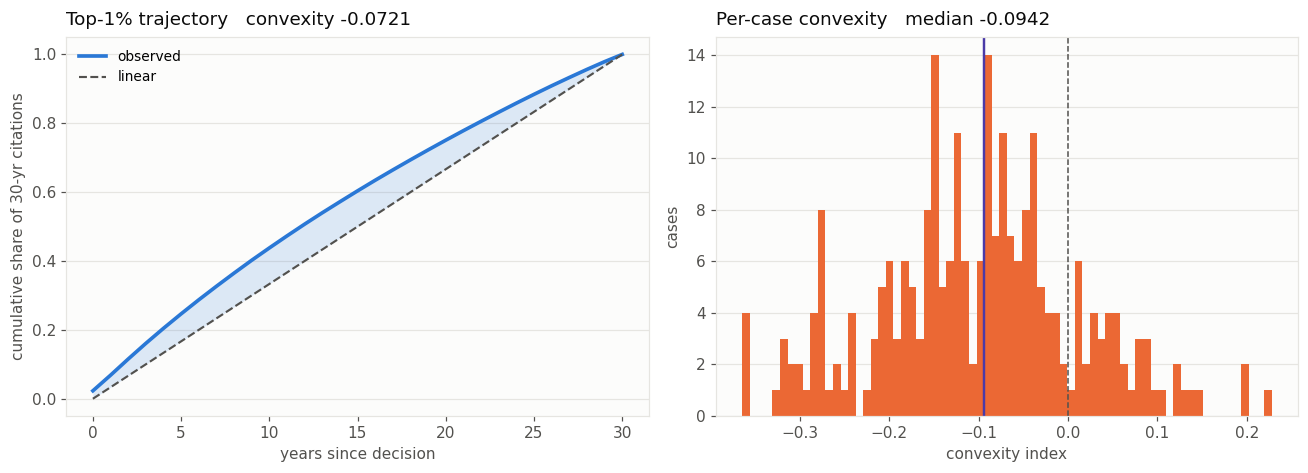

245 top-1% cases sampled | convex (>0) 17.6%  concave 82.4%
  positive = citations arrive late; negative = early
CPU times: user 3.74 s, sys: 157 ms, total: 3.89 s
Wall time: 1.7 s


In [16]:
%%time
AGE = 30
traj = con.execute(f"""
WITH elig AS (
  SELECT h.case_id FROM read_parquet('{HIT}') h
  JOIN read_parquet('{META}') m USING (case_id)
  WHERE h.pctl_C_all >= 0.99 AND m.decision_year BETWEEN 1900 AND {SNAP - AGE}
),
t AS (SELECT t.case_id, t.yrs_since_decision AS age, t.C FROM read_parquet('{TRD}') t
      JOIN elig USING (case_id) WHERE t.yrs_since_decision <= {AGE})
SELECT age, sum(C)::DOUBLE / (SELECT count(*) FROM elig) AS per_case FROM t
GROUP BY 1 ORDER BY 1""").fetchdf()
cum = traj.per_case.cumsum(); cum = cum / cum.iloc[-1]
line = np.linspace(0, 1, len(cum))
convexity = float((line - cum.values).mean())

# per-case convexity, on a sample, so the spread is visible and not just the mean curve
pc = con.execute(f"""
WITH elig AS (
  SELECT h.case_id FROM read_parquet('{HIT}') h JOIN read_parquet('{META}') m USING (case_id)
  WHERE h.pctl_C_all >= 0.99 AND m.decision_year BETWEEN 1900 AND {SNAP - AGE}
  USING SAMPLE 40000 ROWS)
SELECT t.case_id, t.yrs_since_decision AS age, t.C FROM read_parquet('{TRD}') t
JOIN elig USING (case_id) WHERE t.yrs_since_decision <= {AGE}""").fetchdf()
def conv(g):
    c = np.zeros(AGE + 1)
    c[g.age.values] = g.C.values
    c = np.cumsum(c)
    if c[-1] <= 0:
        return np.nan
    c = c / c[-1]
    return float((np.linspace(0, 1, AGE + 1) - c).mean())
ci = pc.groupby('case_id').apply(conv, include_groups=False).dropna()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4), layout='constrained')
ax[0].plot(range(len(cum)), cum, lw=2.4, color=BLUE, label='observed')
ax[0].plot(range(len(cum)), line, lw=1.4, color=MUTED, ls='--', label='linear')
ax[0].fill_between(range(len(cum)), line, cum, color=BLUE, alpha=.15, lw=0)
style(ax[0], 'years since decision', 'cumulative share of 30-yr citations',
      f'Top-1% trajectory   convexity {convexity:+.4f}')
ax[0].legend(frameon=False, fontsize=9)
ax[1].hist(ci, bins=70, color=ORANGE)
ax[1].axvline(0, color=MUTED, lw=1, ls='--')
ax[1].axvline(ci.median(), color=VIOLET, lw=1.6)
style(ax[1], 'convexity index', 'cases', f'Per-case convexity   median {ci.median():+.4f}')
V.save('12')
print(f'{len(ci):,} top-1% cases sampled | convex (>0) {(ci>0).mean()*100:.1f}%  '
      f'concave {(ci<0).mean()*100:.1f}%')
print('  positive = citations arrive late; negative = early')

## 13. Is case law becoming less disruptive?

The Park, Leahey & Funk (2023, Fig. 1) construction, on courts instead of papers and patents:
mean CD by decision year, each window on its own axis, restricted to years whose window has
closed and which hold at least 500 defined cases.

**Read this as a check on the pipeline, not as a result.** Three confounds sit on top of any
real trend, and none is corrected here:

- **corpus composition** — which courts and reporters CAP digitised is not constant over time;
- **reference inflation** — `ref_count` rises through the century (§2, right panel), and CD's
  denominator moves with it;
- **truncation** — handled by cutting the series, which is why each panel ends at a different
  year. `CD_all` has no year at which its window closes — it only ever gets shorter — so it is
  cut at the widest fixed window's horizon (10 years) as a conservative stand-in, marked on
  the panel. An earlier revision mapped it to a zero-year horizon, which switched the guard
  off on the one series that needs it most and overstated its decline.

What the pipeline is being asked here is only whether it produces a series with the same
qualitative shape the other two families produce. If it does, the CD implementation transfers.

/project/jevans/Dawoon/Science of Science/validation/val_common.py:96: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] case_law_validation_13.jpg + .pdf  (600 dpi)


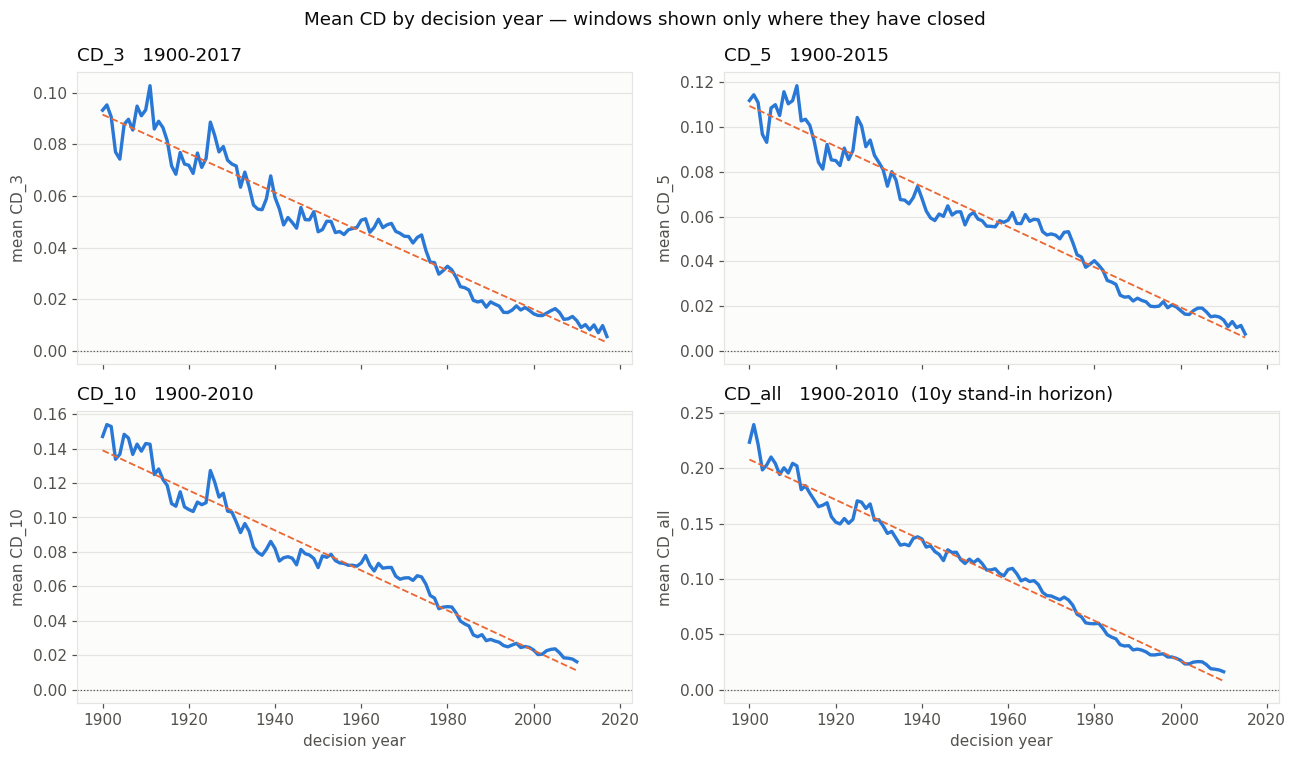

,window,from,to,first_10yr_mean,last_10yr_mean,change,slope_per_year
0,CD_3,1900,2017,0.08790,0.00970,-0.07821,-0.00075
1,CD_5,1900,2015,0.10770,0.01301,-0.09470,-0.00090
2,CD_10,1900,2010,0.14365,0.02031,-0.12334,-0.00116
3,CD_all,1900,2010,0.20920,0.02163,-0.18757,-0.00182



Caveat: composition, reference inflation and truncation are all uncorrected here.
This section validates that the CD implementation transfers, not that law changed.
CPU times: user 1.96 s, sys: 57.4 ms, total: 2.02 s
Wall time: 2.03 s


In [17]:
%%time
feg = pd.read_parquet(FEG)
fig, ax = plt.subplots(2, 2, figsize=(12, 7), sharex=True, layout='constrained')
summary = []
# An all-time window never 'closes' -- it gets SHORTER the nearer a case sits to the
# snapshot, so it is the series most damaged by truncation, not the least. Mapping it to
# 0 disabled the guard on exactly the wrong series. It is given the widest fixed window's
# horizon (10y) as a conservative stand-in, and the guide is labelled as a stand-in.
CLOSE_H = {'_3': 3, '_5': 5, '_10': 10, '_all': 10}
for a, s in zip(ax.ravel(), ('_3', '_5', '_10', '_all')):
    closed = SNAP - CLOSE_H[s]
    g = feg[(feg[f'n{s}_defined'] >= 500) & (feg.year <= closed) & (feg.year >= 1900)]
    a.plot(g.year, g[f'CD{s}_mean'], lw=2.2, color=BLUE)
    a.axhline(0, color=MUTED, lw=.8, ls=':')
    style(a, None, f'mean CD{s}',
          f'CD{s}   1900-{int(g.year.max())}' + ('  (10y stand-in horizon)' if s == '_all' else ''))
    if len(g) > 10:
        z = np.polyfit(g.year, g[f'CD{s}_mean'], 1)
        a.plot(g.year, np.poly1d(z)(g.year), lw=1.2, color=ORANGE, ls='--')
        first = g[f'CD{s}_mean'].iloc[:10].mean(); last = g[f'CD{s}_mean'].iloc[-10:].mean()
        summary.append((f'CD{s}', int(g.year.min()), int(g.year.max()), first, last,
                        last - first, z[0]))
for a in ax[-1]:
    a.set_xlabel('decision year', color=MUTED)
fig.suptitle('Mean CD by decision year — windows shown only where they have closed',
             fontsize=12, color=INK)
V.save('13')
display(pd.DataFrame(summary, columns=['window', 'from', 'to', 'first_10yr_mean',
                                       'last_10yr_mean', 'change', 'slope_per_year']).round(5))
print('\nCaveat: composition, reference inflation and truncation are all uncorrected here.')
print('This section validates that the CD implementation transfers, not that law changed.')

## 14. Stratified validation — All / State / Federal × Overall / Supreme

Everything above pools 5.18M cases from a trial court in Guam and the Supreme Court of the
United States into one distribution. This section splits them.

### How the strata are defined, and why not by name

**Level** comes from `jurisdiction`: `U.S.` is **Federal**; the fifty state abbreviations are
**State**; the remaining ten — D.C., P.R., V.I., Guam, Am. Samoa, N. Mar. I., Tribal, Navajo
Nation, Dakota Territory and two U.K. cases, 63,867 in total — are **Other**, reported
separately rather than folded into "State", which would make state law mean something it does
not.

**Supreme** is the harder one. Not one court name in the corpus contains the word "Supreme"
(measured: **0 of 5,179,698**), so a name match finds nothing. Matching `Sup. Ct.` is worse
than useless — `N.Y. Sup. Ct.` is New York's **trial** court (80,530 cases), while its highest
court is the Court of Appeals, abbreviated `N.Y.`. The rule that works is CAP's own convention:

> **the highest court of a jurisdiction is the one whose abbreviation equals the
> jurisdiction's abbreviation.**

That gives `U.S.`/`U.S.` = the Supreme Court of the United States (51,702 cases from 1800) and
each state's own line as its supreme court (42.6% of state cases — state supreme courts are a
far larger share of the digitised state record than SCOTUS is of the federal one, where the
circuit and district courts dominate).

The definition lives in `cl_common.strata_sql()` so this notebook and any later one cannot
drift apart on it.

In [18]:
%%time
# F/E/G on the 5-YEAR window. An all-time window never closes -- it only gets shorter the
# nearer a document sits to the snapshot -- so it is the worst of the four for comparing
# across time, not the best. Five years closes, and by then most documents that will ever
# cite have done so. CD and ni/nj/nk are left on their own window on purpose: they are the
# disruption block, not the F/E/G block.
import cl_common as cl_
# The strata expression is qualified with the alias of the table it reads INSIDE the CTE
# (`src`), not with the CTE's own name (`m`) -- inside `WITH m AS (...)` the name `m` does not
# exist yet, and qualifying with it is a binder error.
STRATA = cl_.strata_sql('src')
base = f"""
WITH m AS (SELECT src.case_id, src.decision_year, src.jurisdiction, src.court, src.ref_count,
                  {STRATA}
           FROM read_parquet('{META}') AS src WHERE src.decision_year >= {cl_.YEAR_MIN})
"""
tab = con.execute(base + f"""
SELECT m.level, CASE WHEN m.is_supreme THEN 'Supreme' ELSE 'Lower' END AS bench,
       count(*) AS cases,
       round(avg(m.ref_count), 2)                        AS mean_refs,
       round(avg(c.C_all), 2)                            AS mean_C_all,
       round(avg(c.C_10), 2)                             AS mean_C_10,
       round(avg(d.CD_all), 4)                           AS mean_CD_all,
       round(avg(d.F_5), 3)  AS F, round(avg(d.E_5), 3) AS E, round(avg(d.G_5), 3) AS G,
       round(avg(s.SB_B), 2)                             AS mean_SB_B,
       round(median(s.SB_T), 1)                          AS median_SB_T
FROM m JOIN read_parquet('{CIT}') c USING (case_id)
       LEFT JOIN read_parquet('{DIS}') d USING (case_id)
       LEFT JOIN read_parquet('{SB}')  s USING (case_id)
GROUP BY 1, 2 ORDER BY 1, 2 DESC""").fetchdf()
allrow = con.execute(base + f"""
SELECT 'All' AS level, 'Overall' AS bench, count(*) AS cases,
       round(avg(m.ref_count),2), round(avg(c.C_all),2), round(avg(c.C_10),2),
       round(avg(d.CD_all),4), round(avg(d.F_5),3), round(avg(d.E_5),3), round(avg(d.G_5),3),
       round(avg(s.SB_B),2), round(median(s.SB_T),1)
FROM m JOIN read_parquet('{CIT}') c USING (case_id)
       LEFT JOIN read_parquet('{DIS}') d USING (case_id)
       LEFT JOIN read_parquet('{SB}')  s USING (case_id)""").fetchdf()
allrow.columns = tab.columns
display(pd.concat([allrow, tab], ignore_index=True))
print(f'All analysis floored at {cl_.YEAR_MIN}.  Supreme = court abbreviation == jurisdiction.')

,level,bench,cases,mean_refs,mean_C_all,mean_C_10,mean_CD_all,F,E,G,mean_SB_B,median_SB_T
0,All,Overall,5177903,9.18,9.17,4.72,0.1206,0.071,0.524,0.405,5.99,2.0
1,Federal,Supreme,51702,9.33,123.27,42.10,0.2498,0.142,0.439,0.419,22.09,4.0
2,Federal,Lower,1312491,12.41,9.05,6.02,0.0518,0.080,0.639,0.280,3.67,1.0
3,Other,Supreme,40157,9.47,6.76,3.54,0.1412,0.069,0.541,0.390,6.31,3.0
4,Other,Lower,23710,11.86,2.07,1.33,0.0788,0.047,0.582,0.372,6.36,3.0
5,State,Supreme,1597628,8.78,11.83,4.99,0.1748,0.075,0.460,0.465,8.80,4.0
6,State,Lower,2152215,7.46,4.66,2.88,0.1065,0.061,0.507,0.432,4.36,2.0


All analysis floored at 1800.  Supreme = court abbreviation == jurisdiction.
CPU times: user 8.06 s, sys: 427 ms, total: 8.48 s
Wall time: 1.43 s


/project/jevans/Dawoon/Science of Science/validation/val_common.py:96: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] case_law_validation_14.jpg + .pdf  (600 dpi)


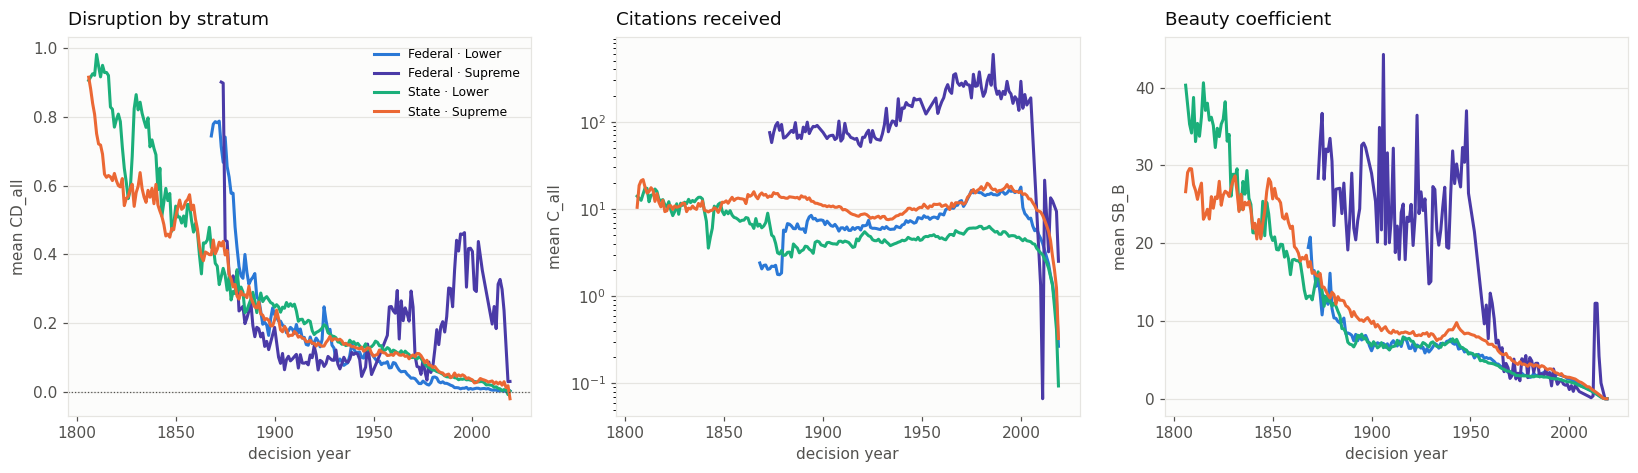

CPU times: user 6.34 s, sys: 300 ms, total: 6.64 s
Wall time: 2.7 s


['/project/jevans/Dawoon/Science of Science/validation/Figures/case_law_validation_14.jpg',
 '/project/jevans/Dawoon/Science of Science/validation/Figures/case_law_validation_14.pdf']

In [19]:
%%time
# CD, citations and SB by decision year, one line per stratum. Restricted to years holding at
# least 200 defined cases in that stratum, so a thin early stratum does not draw a spike.
tr = con.execute(base + f"""
SELECT m.level, m.is_supreme, m.decision_year AS year, count(*) AS n,
       avg(d.CD_all) AS cd, avg(c.C_all) AS cite, avg(s.SB_B) AS sb,
       count(d.CD_all) AS n_cd
FROM m JOIN read_parquet('{CIT}') c USING (case_id)
       LEFT JOIN read_parquet('{DIS}') d USING (case_id)
       LEFT JOIN read_parquet('{SB}')  s USING (case_id)
WHERE m.level <> 'Other'
GROUP BY 1, 2, 3 HAVING count(*) >= 200 ORDER BY 1, 2, 3""").fetchdf()
tr['stratum'] = tr.level + ' · ' + np.where(tr.is_supreme, 'Supreme', 'Lower')
COL = {'Federal · Supreme': VIOLET, 'Federal · Lower': BLUE,
       'State · Supreme': ORANGE, 'State · Lower': AQUA}
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4), layout='constrained')
for st, g in tr.groupby('stratum'):
    c = COL.get(st, MUTED)
    ax[0].plot(g.year, g.cd, lw=2, color=c, label=st)
    ax[1].plot(g.year, g.cite, lw=2, color=c, label=st)
    ax[2].plot(g.year, g.sb, lw=2, color=c, label=st)
ax[0].axhline(0, color=MUTED, lw=.8, ls=':')
style(ax[0], 'decision year', 'mean CD_all', 'Disruption by stratum')
style(ax[1], 'decision year', 'mean C_all', 'Citations received'); ax[1].set_yscale('log')
style(ax[2], 'decision year', 'mean SB_B', 'Beauty coefficient')
ax[0].legend(frameon=False, fontsize=8)
V.save('14')

/project/jevans/Dawoon/Science of Science/validation/val_common.py:96: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] case_law_validation_14b.jpg + .pdf  (600 dpi)


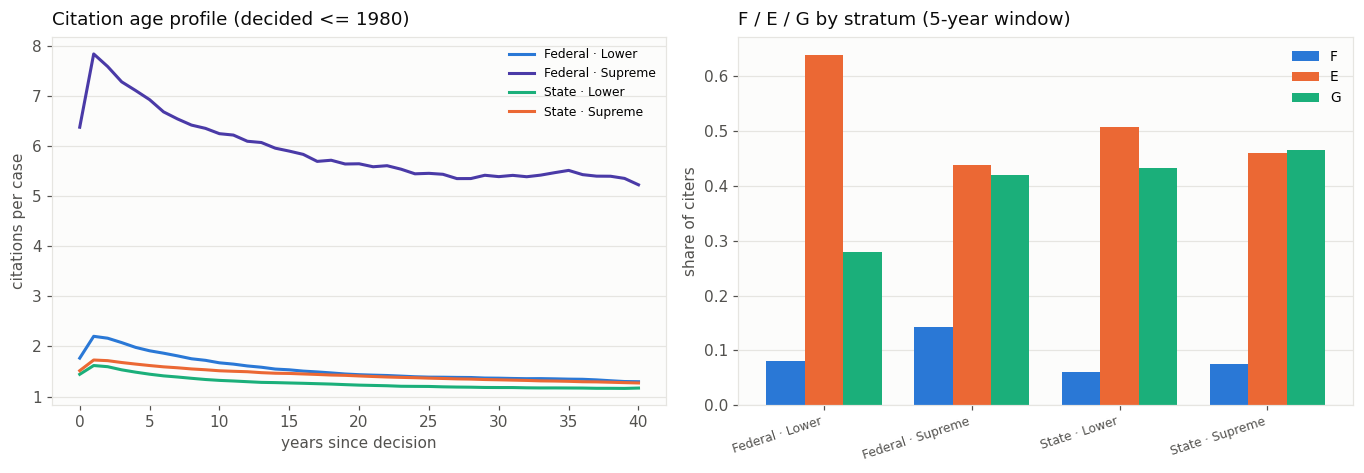

,stratum,F,E,G
0,Federal · Lower,0.0803,0.6394,0.2803
1,Federal · Supreme,0.1421,0.4387,0.4192
2,State · Lower,0.0614,0.5068,0.4318
3,State · Supreme,0.0750,0.4604,0.4647


CPU times: user 7.95 s, sys: 305 ms, total: 8.25 s
Wall time: 2.31 s


In [20]:
%%time
# The four strata side by side on the two shapes that matter: the citation age profile and the
# F/E/G split. A stratum whose age profile differs materially is a stratum whose fixed-window
# metrics are not comparable with the others'.
prof = con.execute(base + f"""
SELECT m.level, m.is_supreme, t.yrs_since_decision AS age,
       sum(t.C)::DOUBLE / count(DISTINCT t.case_id) AS per_case
FROM m JOIN read_parquet('{TRD}') t USING (case_id)
WHERE m.level <> 'Other' AND t.yrs_since_decision <= 40 AND m.decision_year <= 1980
GROUP BY 1, 2, 3 ORDER BY 1, 2, 3""").fetchdf()
prof['stratum'] = prof.level + ' · ' + np.where(prof.is_supreme, 'Supreme', 'Lower')
feg4 = con.execute(base + f"""
SELECT m.level, m.is_supreme, avg(d.F_5) AS F, avg(d.E_5) AS E, avg(d.G_5) AS G
FROM m JOIN read_parquet('{DIS}') d USING (case_id)
WHERE m.level <> 'Other' AND d.F_5 IS NOT NULL GROUP BY 1, 2 ORDER BY 1, 2""").fetchdf()
feg4['stratum'] = feg4.level + ' · ' + np.where(feg4.is_supreme, 'Supreme', 'Lower')

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4), layout='constrained')
for st, g in prof.groupby('stratum'):
    ax[0].plot(g.age, g.per_case, lw=2, color=COL.get(st, MUTED), label=st)
style(ax[0], 'years since decision', 'citations per case',
      'Citation age profile (decided <= 1980)')
ax[0].legend(frameon=False, fontsize=8)
x = np.arange(len(feg4)); w = .26
for i, (col, c) in enumerate((('F', BLUE), ('E', ORANGE), ('G', AQUA))):
    ax[1].bar(x + (i - 1) * w, feg4[col], w, color=c, label=f'{col}')
ax[1].set_xticks(x); ax[1].set_xticklabels(feg4.stratum, rotation=18, ha='right', fontsize=8)
style(ax[1], None, 'share of citers', 'F / E / G by stratum (5-year window)')
ax[1].legend(frameon=False, fontsize=9)
V.save('14b')
display(feg4[['stratum', 'F', 'E', 'G']].round(4))